In [1]:
import json
import os
import sys
from my_plot import *

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *
from file_reader import *

import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index --Extension"

### Parameters

In [2]:
data_names = [
    "us_1000000"
]

display_data_names = ["US"]

# Patterns for file naming conventions
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"

# Patterns for specific queries
real_point_name = "{data_name}_point_200000_2_uniform_1"
real_knn_name = "{data_name}_knn_1000_2_uniform_1"

# Range patterns
real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"

# Baselines and display names
baselines = ['rlrtree', 'bmtree', 'qdtree']
display_baselines = ['RLR-tree', 'BM-tree', 'Qd-tree']


baselines = ['rlrtree', ]
display_baselines = ['RLR-tree', ]

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

# Suffixes for different baseline configurations
baseline_suffixs = [
    {'qdtree': '_episode_10_sampling_ratio_0.0001_action_space_800', 'rlrtree': '_rlrtree_epoch_6_sample_10000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0001_action_space_400', 'rlrtree': '_rlrtree_epoch_8_sample_10000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_200', 'rlrtree': '_rlrtree_epoch_10_sample_10000'},
    {'bmtree': '_bits_32_depth_8_sample_10000', 'qdtree': '_episode_10_sampling_ratio_0.0002_action_space_800'},
    {'bmtree': '_bits_32_depth_10_sample_10000', 'qdtree': '_episode_10_sampling_ratio_0.0002_action_space_400'},
    {'bmtree': '_bits_32_depth_12_sample_10000', 'qdtree': '_episode_10_sampling_ratio_0.0002_action_space_200', 'rlrtree': '_rlrtree_epoch_6_sample_20000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_800', 'rlrtree': '_rlrtree_epoch_8_sample_20000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_400', 'rlrtree': '_rlrtree_epoch_10_sample_20000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_200'},
    {'bmtree': '_bits_32_depth_8_sample_20000', 'qdtree': '_episode_10_sampling_ratio_0.0008_action_space_800'},
    {'bmtree': '_bits_32_depth_10_sample_20000', 'qdtree': '_episode_10_sampling_ratio_0.0008_action_space_400', 'rlrtree': '_rlrtree_epoch_6_sample_40000'},
    {'bmtree': '_bits_32_depth_10_sample_20000', 'qdtree': '_episode_10_sampling_ratio_0.0008_action_space_200', 'rlrtree': '_rlrtree_epoch_8_sample_40000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0016_action_space_800', 'rlrtree': '_rlrtree_epoch_10_sample_40000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0016_action_space_400'},
    {'qdtree': '_episode_10_sampling_ratio_0.0016_action_space_200'},
    {'bmtree': '_bits_32_depth_8_sample_40000', 'rlrtree': '_rlrtree_epoch_6_sample_80000'},
    {'bmtree': '_bits_32_depth_10_sample_40000', 'rlrtree': '_rlrtree_epoch_8_sample_80000'},
    {'bmtree': '_bits_32_depth_12_sample_40000', 'rlrtree': '_rlrtree_epoch_10_sample_80000'},
    {'bmtree': '_bits_32_depth_10_sample_80000'},
    {'bmtree': '_bits_32_depth_10_sample_160000'},
]

# Paths for storing results
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"

rl_methods = [0, 1]
gammas = [0.9, 0.7]
epochs1 = [6, 8, 10]
epochs2 = [12, 14]
epochs=[6, 8, 10,12, 14]
learning_rates = [0.01, 0.001, 0.0001]
samples = [1000, 2000, 4000, 8000]

tmpl1="_rlrtree_epoch_{}_sample_{}_network_sort_spl_loc_learning_rate_{}_action_space_2"
tmpl2="_rlrtree_epoch_{}_sample_{}_gamma_{}_learning_rate_{}_rl_method_{}"

config_template = {"epoch":6,
                   "sample":1000,
                   "learning_rate":0.01,
                   "rl_method":0,
                   "gamma":0.8
                  }

# baseline_suffixs= 

In [3]:
# Build lists
names1 = [
    tmpl1.format(e, s, lr)
    for e in epochs1
    for s in samples
    for lr in learning_rates
]


names4 = [
    tmpl2.format(e, s, 0.8, 0.01, 0)
    for e in epochs2
    for s in samples
    for lr in learning_rates
]

names2 = [
    tmpl2.format(e, s, g, 0.01, 0)
    for e in epochs
    for s in samples
    for g in gammas
]

names3 = [
    tmpl2.format(e, s, 0.8, 0.01, 1)
    for e in epochs
    for s in samples
]
baseline_suffixs = []
baseline_suffixs.extend(names1)
baseline_suffixs.extend(names2)
baseline_suffixs.extend(names3)
baseline_suffixs.extend(names4)

In [4]:
# import re
# from copy import deepcopy

# # DEFAULT_CONFIG = {"epoch": 6, "sample": 1000, "learning_rate": 0.01, "rl_method": 0, "gamma": 0.8}

# PAT1 = re.compile(r"_rlrtree_epoch_(?P<epoch>[^_]+)_sample_(?P<sample>[^_]+)_network_sort_spl_loc_learning_rate_(?P<learning_rate>[^_]+)_action_space_2$")
# PAT2 = re.compile(r"_rlrtree_epoch_(?P<epoch>[^_]+)_sample_(?P<sample>[^_]+)_gamma_(?P<gamma>[^_]+)_learning_rate_(?P<learning_rate>[^_]+)_rl_method_(?P<rl_method>[^_]+)$")

# def _to_num(s: str):
#     if re.fullmatch(r"[+-]?\d+", s):
#         return int(s)
#     return float(s)

# def parse_baseline_suffix(s: str, config_template: dict = None) -> dict:
#     cfg = deepcopy(config_template) if config_template is not None else deepcopy(config_template)

#     m = PAT2.search(s)
#     if m:
#         cfg["epoch"] = _to_num(m.group("epoch"))
#         cfg["sample"] = _to_num(m.group("sample"))
#         cfg["gamma"] = _to_num(m.group("gamma"))
#         cfg["learning_rate"] = _to_num(m.group("learning_rate"))
#         cfg["rl_method"] = _to_num(m.group("rl_method"))
#         return {k: cfg[k] for k in ("epoch", "sample", "learning_rate", "rl_method", "gamma")}

#     m = PAT1.search(s)
#     if m:
#         cfg["epoch"] = _to_num(m.group("epoch"))
#         cfg["sample"] = _to_num(m.group("sample"))
#         cfg["learning_rate"] = _to_num(m.group("learning_rate"))
#         return {k: cfg[k] for k in ("epoch", "sample", "learning_rate", "rl_method", "gamma")}

#     raise ValueError(f"Unrecognized baseline_suffix: {s}")

import re

DEF = {"epoch": 6, "sample": 1000, "learning_rate": 0.01, "rl_method": 0, "gamma": 0.8}

NUM = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"


PAT1 = re.compile(
    fr"_rlrtree_epoch_(?P<epoch>{NUM})_sample_(?P<sample>{NUM})_network_sort_spl_loc_"
    fr"learning_rate_(?P<learning_rate>{NUM})_action_space_2"
)
PAT2 = re.compile(
    fr"_rlrtree_epoch_(?P<epoch>{NUM})_sample_(?P<sample>{NUM})_gamma_(?P<gamma>{NUM})_"
    fr"learning_rate_(?P<learning_rate>{NUM})_rl_method_(?P<rl_method>{NUM})"
)

def _to_num(s: str):

    return int(s) if re.fullmatch(r"[+-]?\d+", s) else float(s)

def parse_baseline_suffix(s: str, config_template: dict = None) -> dict:
    defaults = {**DEF, **(config_template or {})} 
    m = PAT2.search(s) or PAT1.search(s)
    if not m:
        raise ValueError(f"Unrecognized baseline_suffix: {s}")

    out = dict(defaults) 
    gd = m.groupdict()
    for k in ("epoch", "sample", "learning_rate", "rl_method", "gamma"):
        if gd.get(k) is not None: 
            out[k] = _to_num(gd[k])
    return out

In [5]:
def read_results(baseline_suffixs):

    point_query = []
    range_query = []
    knn_query = []
    point_query_IO = []
    range_query_IO = []
    knn_query_IO = []
    build_time = []
    configs = []
    
    
    dataset_performance = {}
    dataset_performance_IO = {}
    
    for i, data_name in enumerate(data_names):
    
        point_query_dataset = []
        range_query_dataset = []
        knn_query_dataset = []
        point_query_IO_dataset = []
        range_query_IO_dataset = []
        knn_query_IO_dataset = []
        build_time_dataset = []
        configs_dataset = []
    
        index_performance = {'bmtree':{}, 'rlrtree':{}, 'qdtree':{}}
        index_performance_IO = {'bmtree':{}, 'rlrtree':{}, 'qdtree':{}}
        
        for baseline in baselines:
        
            point_query_sampled = []
            range_query_sampled = []
            knn_query_sampled = []
            point_query_sampled_IO = []
            range_query_sampled_IO = []
            knn_query_sampled_IO = []
            build_time_sampled = []
            configs_sampled = []
            
            # for baseline in baselines:
            
            query_range = 0.001
            k=25
        
            for baseline_suffix in baseline_suffixs:
     
                suffix = baseline_suffix
                config = parse_baseline_suffix(suffix)


        
                if data_name.startswith("data"):
                    range_name = synthetic_range_name_pattern.format(r1=query_range,r2=query_range)
                    point_name = synthetic_point_name.format(data_name=data_name)
                    knn_name = synthetic_knn_name
                    default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
                else:
                    range_name=real_range_name_pattern.format(data_name=data_name,r1=query_range,r2=query_range)
                    point_name = real_point_name.format(data_name=data_name)
                    knn_name = real_knn_name.format(data_name=data_name)
                    default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
                build_result_name = build_result_name_pattern.format(
                    data_name=data_name,
                    default_range_name=default_range_name,
                    suffix=suffix
                )
        
                # print(build_result_name)
                res = os.path.join(build_result_path.format(name=baseline), build_result_name)
                # print(res)
                tree_property = parse_rtree_properties(res)
                build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9)
                
                # build_time_sampled.append((tree_property.ElapsedBuildTime + tree_property.ElapsedLearnTime) / 1e9)
        
                point_result_name = point_result_name_pattern.format(
                    data_name=data_name,
                    point_name=point_name,
                    default_range_name=default_range_name,
                    suffix=suffix
                )
                
                res = os.path.join(point_result_path.format(name=baseline), point_result_name)
                tree_property = parse_rtree_properties(res)
                # print(res)
                point_query_sampled_IO.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
                point_query_sampled.append(tree_property.QueryMean / 1e3)
        
                range_result_name = range_result_name_pattern.format(
                    data_name=data_name,
                    range_name=range_name,
                    suffix=suffix
                )
                res = os.path.join(range_result_path.format(name=baseline), range_result_name)
                tree_property = parse_rtree_properties(res)
                range_query_sampled_IO.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
                range_query_sampled.append(tree_property.QueryMean / 1e3)
        
                knn_result_name = knn_result_name_pattern.format(
                    data_name=data_name,
                    knn_name=knn_name,
                    default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
                    suffix=suffix,
                    k=k
                )
                res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
                tree_property = parse_rtree_properties(res)
                knn_query_sampled_IO.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
                knn_query_sampled.append(tree_property.QueryMean / 1e3)
    
                index_performance[baseline][suffix] = {(point_query_sampled[-1], range_query_sampled[-1], knn_query_sampled[-1], build_time_sampled[-1])}
                index_performance_IO[baseline][suffix] = {(point_query_sampled_IO[-1], range_query_sampled_IO[-1], knn_query_sampled_IO[-1], build_time_sampled[-1])}
                configs_sampled.append(config)
                
            # print(baseline)
            point_query_IO_dataset.append(point_query_sampled_IO)
            range_query_IO_dataset.append(range_query_sampled_IO)
            knn_query_IO_dataset.append(knn_query_sampled_IO)
            point_query_dataset.append(point_query_sampled)
            range_query_dataset.append(range_query_sampled)
            knn_query_dataset.append(knn_query_sampled)
            build_time_dataset.append(build_time_sampled)
            configs_dataset.append(configs_sampled)
    
        dataset_performance[display_data_names[i]] = index_performance
        dataset_performance_IO[display_data_names[i]] = index_performance_IO
        
        point_query_IO.append(point_query_IO_dataset)
        range_query_IO.append(range_query_IO_dataset)
        knn_query_IO.append(knn_query_IO_dataset)
        point_query.append(point_query_dataset)
        range_query.append(range_query_dataset)
        knn_query.append(knn_query_dataset)
        build_time.append(build_time_dataset)
        configs.append(configs_dataset)
        
    return point_query_IO, range_query_IO, knn_query_IO, point_query, range_query, knn_query, build_time, dataset_performance, configs
# print(dataset_performance)

In [6]:
def calculate_average_query_score(point, range, knn, type="latency", method='mean'):
    """
    Calculate the average query score based on the chosen method.
    
    Parameters:
    - point: score for point queries
    - range: score for range queries
    - knn: score for k-NN queries
    # - type: in [IO, latency]
    - method: method to calculate the average ('mean', 'weighted', etc.)

    Returns:
    - The calculated average query score
    """
    if method == 'mean':
        return range
        # return (point + range + knn) / 3
    elif method == 'weighted':
        # Example weights, adjust as necessary
        return 0.2 * point_IO + 0.5 * range_IO + 0.3 * knn_IO
    elif method == 'max':
        return max(point_IO, range_IO, knn_IO)
    # Add other methods as needed
    else:
        raise ValueError("Unknown method for average calculation")

In [7]:
point_query_IO, range_query_IO, knn_query_IO, point_query, range_query, knn_query, build_time, dataset_performance, configs = read_results(baseline_suffixs)

In [8]:
build_time

[[[156.190541108,
   159.140703346,
   157.357340283,
   327.918082727,
   321.473785577,
   314.445234968,
   662.390234566,
   671.222786632,
   664.016757458,
   1368.644918777,
   1359.605327978,
   1348.020627025,
   213.176292792,
   213.163243093,
   212.705522863,
   417.187151758,
   421.395191462,
   418.363059237,
   837.702792626,
   866.82829816,
   894.990814237,
   1858.046077959,
   1828.398747731,
   1885.326215217,
   261.97198809,
   251.013483415,
   255.886393484,
   542.999142284,
   539.302551029,
   540.594801314,
   1109.016252641,
   1102.355286159,
   1091.934484821,
   2343.444162395,
   2294.960445583,
   2304.996606218,
   163.364259062,
   176.289310124,
   352.92282397,
   328.335286188,
   682.04660838,
   693.877752833,
   1626.586515972,
   1450.226968639,
   212.813911711,
   288.839311756,
   441.235400821,
   431.531493954,
   898.211598886,
   885.865152319,
   2045.629772277,
   1950.999730096,
   270.008469105,
   267.09462537,
   546.076012609,

In [9]:
best_models = {}
is_save = True
# Iterate over each dataset
for dataset_name, indices in dataset_performance.items():
    best_models[dataset_name] = {}
    
    # Iterate over each index in the dataset
    for index_name, models in indices.items():
        best_model = None
        best_score = float('inf')  # Initialize best score to infinity for comparison
        best_tuple = None

        range_time_list = []
        point_time_list = []
        knn_time_list = []

        # Iterate over each model for the index
        for model_name, query_times_set in models.items():
            # Get the tuple of query times; assuming one tuple per model_name
            point_time, range_time, knn_time, build_t = next(iter(query_times_set))

            if point_time == 0 or range_time == 0 or knn_time == 0 or build_t == 0:
                continue
            
            # Calculate the average query time score (ignoring build time for the selection criterion)
            # average_query_score = (point_time + range_time + knn_time) / 3
            average_query_score = calculate_average_query_score(point_time, range_time, knn_time)
            
            # Update best model if this model has a lower average score
            if average_query_score < best_score:
                best_score = average_query_score
                best_model = model_name
                best_tuple = (point_time, range_time, knn_time, build_t)

            range_time_list.append(range_time)
            point_time_list.append(point_time)
            knn_time_list.append(knn_time)

        if not range_time_list:
            continue
        
        print(dataset_name, index_name, "The improvement of range query is:", max(range_time_list) / min(range_time_list))
        # print(dataset_name, index_name, "The improvement of point query is:", max(point_time_list) / min(point_time_list))
        # print(dataset_name, index_name, "The improvement of knn query is:", max(knn_time_list) / min(knn_time_list))
        
        # Store the best model and its performance metrics for the current index in the current dataset
        best_models[dataset_name][index_name] = {
            'model': best_model,
            'metrics': best_tuple  # Store the tuple (point, range, knn, build)
        }

# Display the best model selection and corresponding metrics for each dataset and index
for dataset, indices in best_models.items():
    print(f"Dataset: {dataset}")
    for index, info in indices.items():
        model = info['model']
        metrics = info['metrics']
        print(f"  Index: {index}, Best Model: {model}, Metrics (Point, Range, KNN, Build): {metrics}")

if is_save:
    output_dict = {}
    # Populate the output dictionary with the desired structure
    for dataset, indices in best_models.items():
        output_dict[dataset] = {}
        for index, info in indices.items():
            model = info['model']
            output_dict[dataset][index] = model
    
    with open("rlrtree_best_models_grid_search.json", "w") as json_file:
        json.dump(output_dict, json_file, indent=4)

US rlrtree The improvement of range query is: 1.762802589092079
Dataset: US
  Index: rlrtree, Best Model: _rlrtree_epoch_6_sample_1000_network_sort_spl_loc_learning_rate_0.0001_action_space_2, Metrics (Point, Range, KNN, Build): (44.695732455, 100.840755, 222.63912100000002, 157.357340283)


120 120
120 120
[[157.357340283]] [[44.695732455]]
120 120


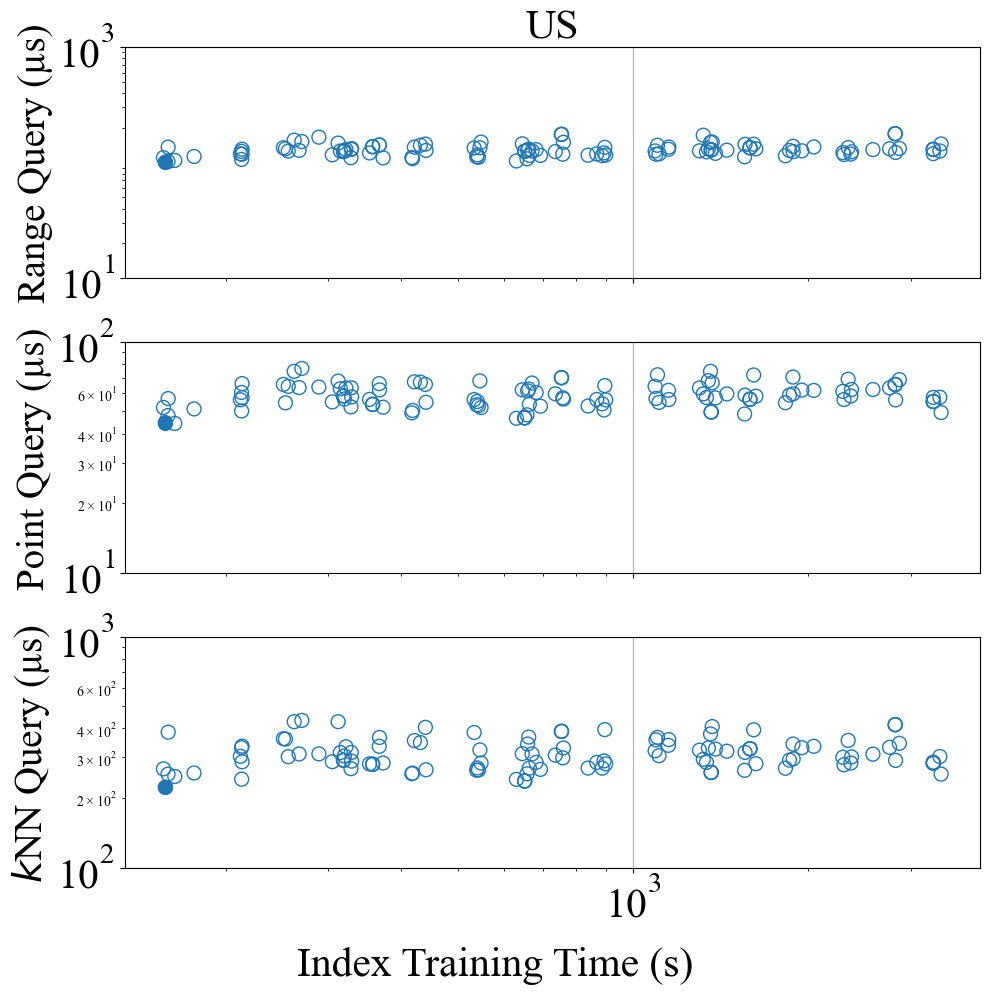

In [10]:
sampled_sizes = [1e4, 2 * 1e4, 4 * 1e4, 8 * 1e4, 16 * 1e4, 32 * 1e4, 64 * 1e4, 128 * 1e4]
query_types = ["Range Query", "Point Query", "$k$NN Query"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10))  # 3 rows for queries, 6 columns for datasets

ranges=[[1e1, 1e3], [1e1, 1e2], [1e2, 1e3]]

for i, query_type in enumerate(query_types):
    for j, dataset in enumerate(display_data_names):
        # Set the correct query data based on the query type
        if query_type == "Point Query":
            query_data = point_query[j]
        elif query_type == "Range Query":
            query_data = range_query[j]
        elif query_type == "$k$NN Query":
            query_data = knn_query[j]

        build_time_dataset = build_time[j]
        config_dataset = configs[j][0]

        print(len(config_dataset), len(build_time_dataset[0]))

        # print(config_dataset)
        # print(build_time_dataset)

        best_build = []
        best_query = []
        indices = best_models[dataset]
        for baseline in baselines:
            point_time, range_time, knn_time, build_t = indices[baseline]['metrics']
            best_build.append([build_t])
            if query_type == "Point Query":
                best_query.append([point_time])
            elif query_type == "Range Query":
                best_query.append([range_time])                
            elif query_type == "$k$NN Query":
                best_query.append([knn_time])      

        plot_scatter(sampled_sizes, display_baselines, build_time_dataset, query_data, best_build, best_query, ax=axes[i], 
                     # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
                     x_label="",  # X label only for bottom row
                     y_label=f"{query_type} (µs)" if j == 0 else "",  # Y label only for left-most column
                     yticks=ranges[i],
                     title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
                     is_log=True, show_legend=(i==0 and j == 5),
                     is_x_ticks=i==2,
                     is_y_ticks=j==0
                    ) #(i==0 and j == 0) # Disable the legend inside the subplots
        if dataset == "US" and query_type == "Point Query":
            print(best_build, best_query)

fig.supxlabel("Index Training Time (s)", fontsize=30) 
plt.tight_layout()
output_file_paths = [folder + "/exp_sigmod/rlrtree_tuning_all.pdf", "../figs/exp_sigmod/rlrtree_tuning_all.png"]
if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')
plt.show()
# print(build_time_dataset, query_data, best_build, best_query)

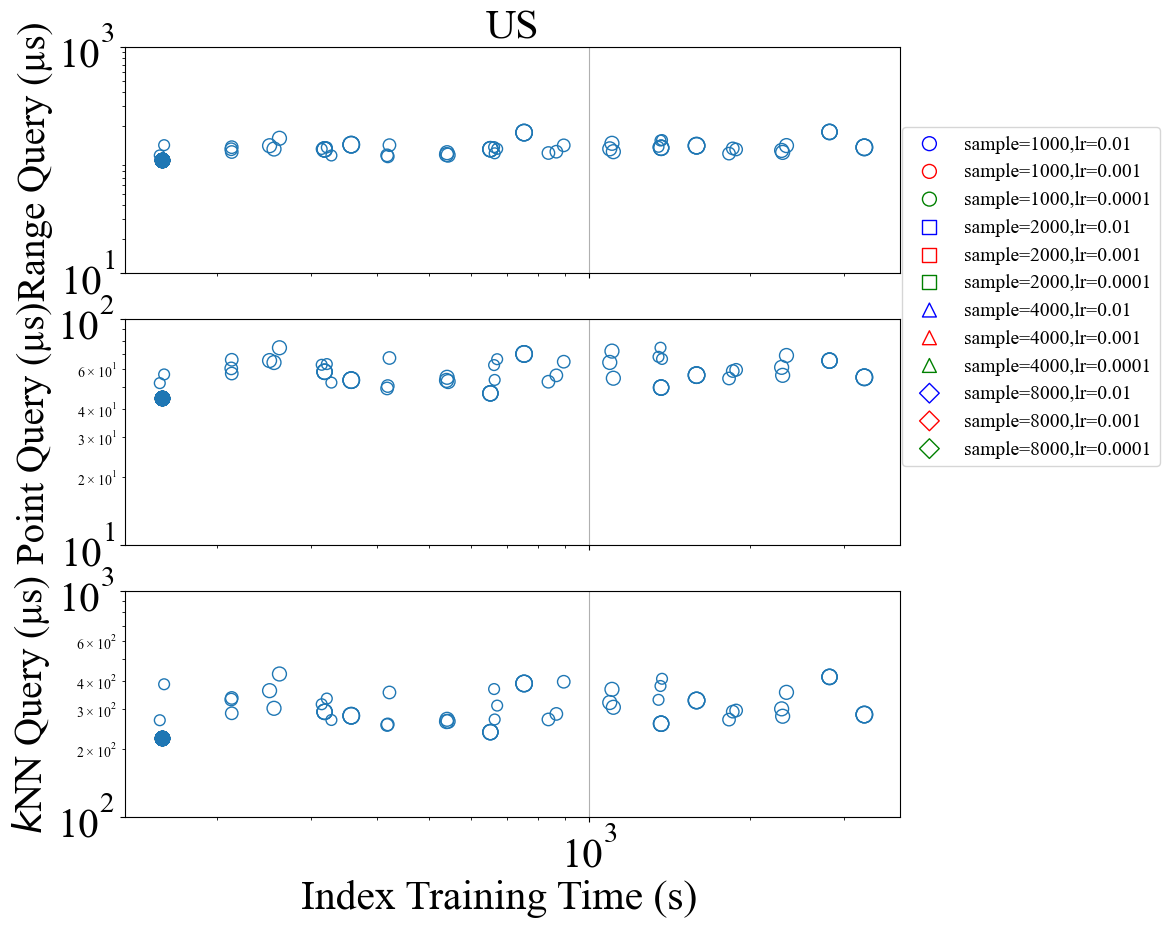

In [11]:
sampled_sizes = [1e4, 2 * 1e4, 4 * 1e4, 8 * 1e4, 16 * 1e4, 32 * 1e4, 64 * 1e4, 128 * 1e4]
query_types = ["Range Query", "Point Query", "$k$NN Query"]
# query_types = ["Range Query"]
fig, axes = plt.subplots(len(query_types), 1, figsize=(10, 10))  # 3 rows for queries, 6 columns for datasets

ranges=[[1e1, 1e3], [1e1, 1e2], [1e2, 1e3]]

for i, query_type in enumerate(query_types):
    for j, dataset in enumerate(display_data_names):
        # Set the correct query data based on the query type
        if query_type == "Point Query":
            query_data = point_query[j]
        elif query_type == "Range Query":
            query_data = range_query[j]
        elif query_type == "$k$NN Query":
            query_data = knn_query[j]

        build_time_dataset = build_time[j]
        config_dataset = configs[j][0]
        

        # print(len(config_dataset), len(build_time_dataset[0]))
        # print(config_dataset)
        # print(build_time_dataset)

        best_build = []
        best_query = []
        indices = best_models[dataset]
        for baseline in baselines:
            point_time, range_time, knn_time, build_t = indices[baseline]['metrics']
            best_build.append([build_t])
            if query_type == "Point Query":
                best_query.append([point_time])
            elif query_type == "Range Query":
                best_query.append([range_time])                
            elif query_type == "$k$NN Query":
                best_query.append([knn_time])

        epoch_handles = []
        epochs = [6,8,10,12,14]
        samples = [1000, 2000, 4000, 8000]
        learning_rates = [0.01, 0.001, 0.0001]
        # for epoch in epochs:
        for sample in samples:
            for learning_rate in learning_rates:
                marker = 'o'
                color = "blue" 
                if sample == 2000:
                    marker = 's'
                if sample == 4000:
                    marker = '^'
                if sample == 8000:
                    marker = 'D'
                if sample == 16000:
                    marker = 'v'
                if learning_rate == 0.01:
                    color = "blue" 
                if learning_rate == 0.001:
                    color = "red" 
                if learning_rate == 0.0001:
                    color = "green" 
                h = plt.scatter([], [], s=100, edgecolors=color, marker = marker,
                                facecolors='none', label=f'sample={sample},lr={learning_rate}')
                epoch_handles.append(h)

        if i == 0:
            # fig.subplots_adjust(right=0.76) 
            leg1 = fig.legend(handles=epoch_handles, fontsize=14,
                         loc='upper right', bbox_to_anchor=(1.16, 0.80),
                         borderaxespad=0.)
            # axes[i].add_artist(leg1)
        
        for k in range(len(config_dataset)):
            # print("config_dataset:", config_dataset[k])

            learning_rate = config_dataset[k]["learning_rate"]
            epoch = config_dataset[k]["epoch"]
            sample = config_dataset[k]["sample"]
            gamma = config_dataset[k]["gamma"]
            rl_method = config_dataset[k]["rl_method"]

            if rl_method != 0:
                continue
            if gamma != 0.8:
                continue
            color = "blue" 
            marker_size = epoch * 10
            marker = 'o'


            # if epoch == 8:
            #     marker_size = 150
            # if epoch == 10:
            #     marker_size = 200
            # if epoch == 12:
            #     marker_size = 250
            # if epoch == 14:
            #     marker_size = 300

            if sample == 2000:
                marker = 's'
            if sample == 4000:
                marker = '^'
            if sample == 8000:
                marker = 'D'
            if sample == 16000:
                marker = 'v'
            
            if learning_rate == 0.001:
                color = "red" 
            if learning_rate == 0.0001:
                color = "green" 
            
            # {'epoch': 6, 'sample': 1000, 'learning_rate': 0.01, 'rl_method': 0, 'gamma': 0.8}
            plot_scatter(sampled_sizes, display_baselines, [[build_time_dataset[0][k]]], [[query_data[0][k]]], best_build, best_query, ax=axes[i], 
                         # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
                         x_label="",  # X label only for bottom row
                         y_label=f"{query_type} (µs)" if j == 0 else "",  # Y label only for left-most column
                         yticks=ranges[i],
                         title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
                         is_log=True, show_legend=False,
                         is_x_ticks=i==2,
                         is_y_ticks=j==0,
                         color=color,
                         marker_size=marker_size,
                         marker=marker
                        ) #(i==0 and j == 0) # Disable the legend inside the subplots

        # if dataset == "US" and query_type == "Point Query":
        #     print(best_build, best_query)

fig.supxlabel("Index Training Time (s)", fontsize=30) 
output_file_paths = [folder + "/exp_sigmod/rlrtree_tuning_lr.pdf", "../figs/exp_sigmod/rlrtree_tuning_lr.png"]
# if output_file_paths:
#     for output_file_path in output_file_paths:
#         if output_file_path.endswith(".pdf"):
#             plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
#         if output_file_path.endswith(".png"):
#             plt.savefig(output_file_path, format='png', bbox_inches='tight')
plt.show()
# print(build_time_dataset, query_data, best_build, best_query)

120 120
[[156.190541108, 159.140703346, 157.357340283, 327.918082727, 321.473785577, 314.445234968, 662.390234566, 671.222786632, 664.016757458, 1368.644918777, 1359.605327978, 1348.020627025, 213.176292792, 213.163243093, 212.705522863, 417.187151758, 421.395191462, 418.363059237, 837.702792626, 866.82829816, 894.990814237, 1858.046077959, 1828.398747731, 1885.326215217, 261.97198809, 251.013483415, 255.886393484, 542.999142284, 539.302551029, 540.594801314, 1109.016252641, 1102.355286159, 1091.934484821, 2343.444162395, 2294.960445583, 2304.996606218, 163.364259062, 176.289310124, 352.92282397, 328.335286188, 682.04660838, 693.877752833, 1626.586515972, 1450.226968639, 212.813911711, 288.839311756, 441.235400821, 431.531493954, 898.211598886, 885.865152319, 2045.629772277, 1950.999730096, 270.008469105, 267.09462537, 546.076012609, 548.583793229, 1152.842574703, 1151.139501148, 2584.421068811, 2368.308756331, 319.492433216, 311.719734704, 645.728582756, 657.881538817, 1321.234372783,

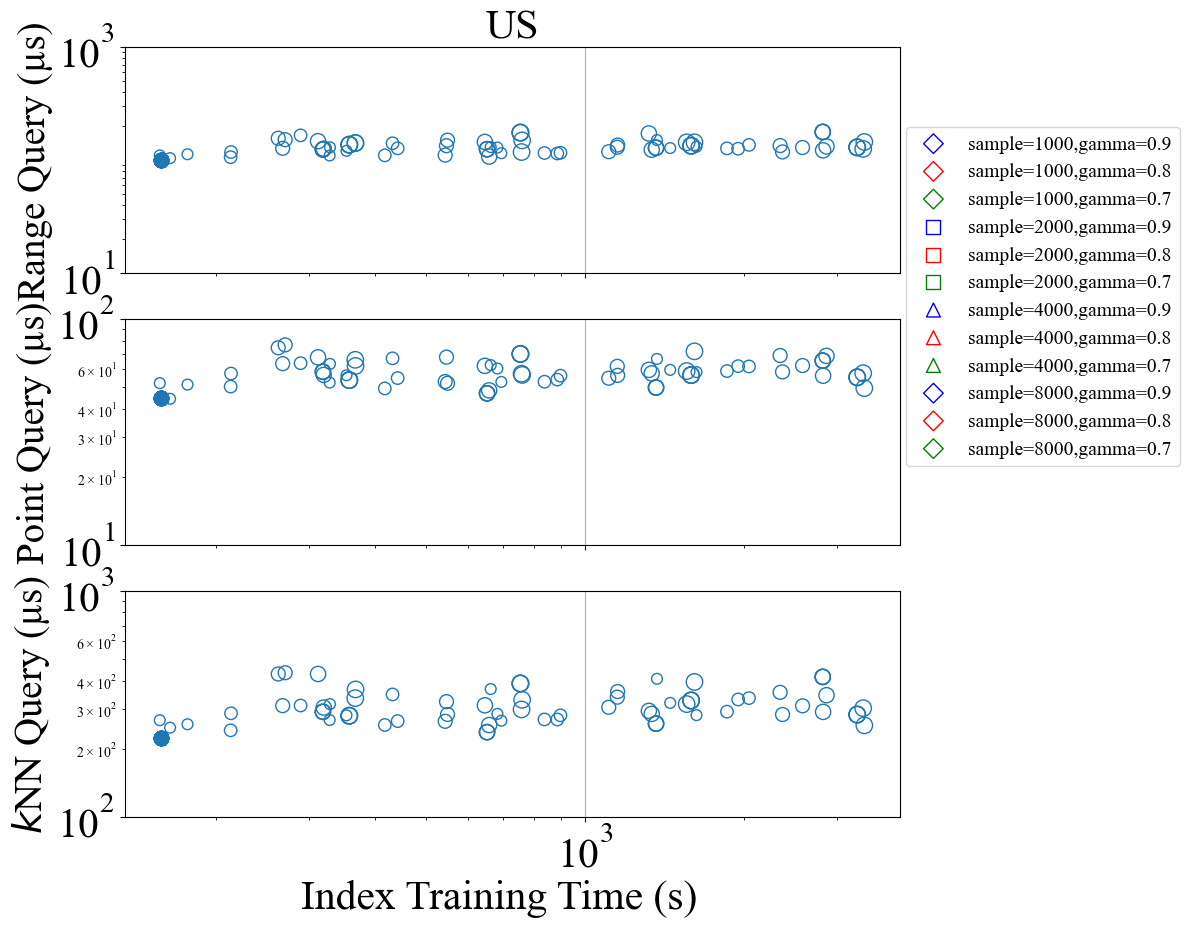

In [12]:
sampled_sizes = [1e4, 2 * 1e4, 4 * 1e4, 8 * 1e4, 16 * 1e4, 32 * 1e4, 64 * 1e4, 128 * 1e4]
query_types = ["Range Query", "Point Query", "$k$NN Query"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10))  # 3 rows for queries, 6 columns for datasets

ranges=[[1e1, 1e3], [1e1, 1e2], [1e2, 1e3]]

for i, query_type in enumerate(query_types):
    for j, dataset in enumerate(display_data_names):
        # Set the correct query data based on the query type
        if query_type == "Point Query":
            query_data = point_query[j]
        elif query_type == "Range Query":
            query_data = range_query[j]
        elif query_type == "$k$NN Query":
            query_data = knn_query[j]

        build_time_dataset = build_time[j]
        config_dataset = configs[j][0]
        

        print(len(config_dataset), len(build_time_dataset[0]))

        # print(config_dataset)
        print(build_time_dataset)

        best_build = []
        best_query = []
        indices = best_models[dataset]
        for baseline in baselines:
            point_time, range_time, knn_time, build_t = indices[baseline]['metrics']
            best_build.append([build_t])
            if query_type == "Point Query":
                best_query.append([point_time])
            elif query_type == "Range Query":
                best_query.append([range_time])                
            elif query_type == "$k$NN Query":
                best_query.append([knn_time])

        epoch_handles = []
        epochs = [6,8,10,12,14]
        samples = [1000, 2000, 4000, 8000]
        gammas = [0.9, 0.8, 0.7]
        # for epoch in epochs:
        for sample in samples:
            for gamma in gammas:
                if sample == 2000:
                    marker = 's'
                if sample == 4000:
                    marker = '^'
                if sample == 8000:
                    marker = 'D'
                if sample == 16000:
                    marker = 'v'
                if gamma == 0.9:
                    color = "blue" 
                if gamma == 0.8:
                    color = "red" 
                if gamma == 0.7:
                    color = "green" 
                h = plt.scatter([], [], s=100, edgecolors=color, marker = marker,
                                facecolors='none', label=f'sample={sample},gamma={gamma}')
                epoch_handles.append(h)

        if i == 0:
            # fig.subplots_adjust(right=0.76) 
            leg1 = fig.legend(handles=epoch_handles,fontsize=14,
                         loc='upper right', bbox_to_anchor=(1.18, 0.80),
                         borderaxespad=0.)
            # axes[i].add_artist(leg1)
        
        for k in range(len(config_dataset)):
            # print("config_dataset:", config_dataset[k])

            learning_rate = config_dataset[k]["learning_rate"]
            epoch = config_dataset[k]["epoch"]
            sample = config_dataset[k]["sample"]
            gamma = config_dataset[k]["gamma"]
            rl_method = config_dataset[k]["rl_method"]

            if rl_method != 0:
                continue
            if learning_rate != 0.01:
                continue
            color = "blue" 
            marker_size = epoch * 10
            marker = 'o'


            # if epoch == 8:
            #     marker_size = 150
            # if epoch == 10:
            #     marker_size = 200
            # if epoch == 12:
            #     marker_size = 250
            # if epoch == 14:
            #     marker_size = 300

            if sample == 2000:
                marker = 's'
            if sample == 4000:
                marker = '^'
            if sample == 8000:
                marker = 'D'
            if sample == 16000:
                marker = 'v'
            
            if gamma == 0.8:
                color = "red" 
            if gamma == 0.7:
                color = "green" 
            
            # {'epoch': 6, 'sample': 1000, 'learning_rate': 0.01, 'rl_method': 0, 'gamma': 0.8}
            plot_scatter(sampled_sizes, display_baselines, [[build_time_dataset[0][k]]], [[query_data[0][k]]], best_build, best_query, ax=axes[i], 
                         # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
                         x_label="",  # X label only for bottom row
                         y_label=f"{query_type} (µs)" if j == 0 else "",  # Y label only for left-most column
                         yticks=ranges[i],
                         title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
                         is_log=True, show_legend=False,
                         is_x_ticks=i==2,
                         is_y_ticks=j==0,
                         color=color,
                         marker_size=marker_size,
                         marker=marker
                        ) #(i==0 and j == 0) # Disable the legend inside the subplots

        if dataset == "US" and query_type == "Point Query":
            print(best_build, best_query)

fig.supxlabel("Index Training Time (s)", fontsize=30) 
output_file_paths = [folder + "/exp_sigmod/rlrtree_tuning_gamma.pdf", "../figs/exp_sigmod/rlrtree_tuning_gamma.png"]
# if output_file_paths:
#     for output_file_path in output_file_paths:
#         if output_file_path.endswith(".pdf"):
#             plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
#         if output_file_path.endswith(".png"):
#             plt.savefig(output_file_path, format='png', bbox_inches='tight')
plt.show()
# print(build_time_dataset, query_data, best_build, best_query)

[[157.357340283]] [[44.695732455]]


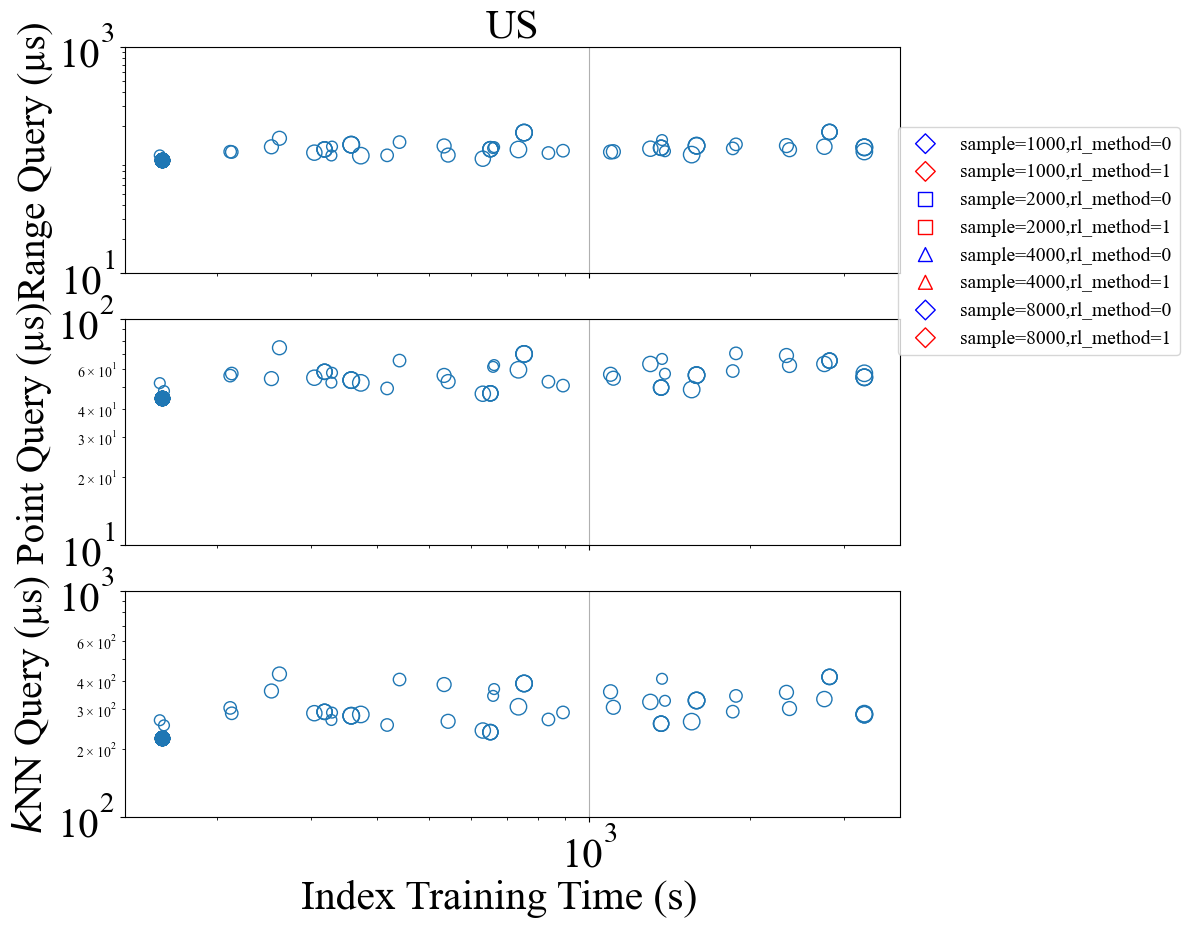

In [13]:
sampled_sizes = [1e4, 2 * 1e4, 4 * 1e4, 8 * 1e4, 16 * 1e4, 32 * 1e4, 64 * 1e4, 128 * 1e4]
query_types = ["Range Query", "Point Query", "$k$NN Query"]
fig, axes = plt.subplots(3, 1, figsize=(10, 10))  # 3 rows for queries, 6 columns for datasets

ranges=[[1e1, 1e3], [1e1, 1e2], [1e2, 1e3]]

for i, query_type in enumerate(query_types):
    for j, dataset in enumerate(display_data_names):
        # Set the correct query data based on the query type
        if query_type == "Point Query":
            query_data = point_query[j]
        elif query_type == "Range Query":
            query_data = range_query[j]
        elif query_type == "$k$NN Query":
            query_data = knn_query[j]

        build_time_dataset = build_time[j]
        config_dataset = configs[j][0]
        

        # print(len(config_dataset), len(build_time_dataset[0]))

        # # print(config_dataset)
        # print(build_time_dataset)

        best_build = []
        best_query = []
        indices = best_models[dataset]
        for baseline in baselines:
            point_time, range_time, knn_time, build_t = indices[baseline]['metrics']
            best_build.append([build_t])
            if query_type == "Point Query":
                best_query.append([point_time])
            elif query_type == "Range Query":
                best_query.append([range_time])                
            elif query_type == "$k$NN Query":
                best_query.append([knn_time])

        epoch_handles = []
        epochs = [6,8,10,12,14]
        samples = [1000, 2000, 4000, 8000]
        rl_methods = [0, 1]
        # for epoch in epochs:
        for sample in samples:
            for rl_method in rl_methods:
                if sample == 2000:
                    marker = 's'
                if sample == 4000:
                    marker = '^'
                if sample == 8000:
                    marker = 'D'
                if sample == 16000:
                    marker = 'v'
                if rl_method == 0:
                    color = "blue" 
                if rl_method == 1:
                    color = "red" 
                # if gamma == 0.7:
                #     color = "green" 
                h = plt.scatter([], [], s=100, edgecolors=color, marker = marker,
                                facecolors='none', label=f'sample={sample},rl_method={rl_method}')
                epoch_handles.append(h)

        if i == 0:
            # fig.subplots_adjust(right=0.76) 
            leg1 = fig.legend(handles=epoch_handles,fontsize=14,
                         loc='upper right', bbox_to_anchor=(1.18, 0.80),
                         borderaxespad=0.)
            # axes[i].add_artist(leg1)
        
        for k in range(len(config_dataset)):
            # print("config_dataset:", config_dataset[k])

            learning_rate = config_dataset[k]["learning_rate"]
            epoch = config_dataset[k]["epoch"]
            sample = config_dataset[k]["sample"]
            gamma = config_dataset[k]["gamma"]
            rl_method = config_dataset[k]["rl_method"]

            if gamma != 0.8:
                continue
            if learning_rate != 0.01:
                continue
            color = "blue" 
            marker_size = epoch * 10
            marker = 'o'


            # if epoch == 8:
            #     marker_size = 150
            # if epoch == 10:
            #     marker_size = 200
            # if epoch == 12:
            #     marker_size = 250
            # if epoch == 14:
            #     marker_size = 300

            if sample == 2000:
                marker = 's'
            if sample == 4000:
                marker = '^'
            if sample == 8000:
                marker = 'D'
            if sample == 16000:
                marker = 'v'
            
            if rl_method == 1:
                color = "red" 
            # if gamma == 0.7:
            #     color = "green" 
            
            # {'epoch': 6, 'sample': 1000, 'learning_rate': 0.01, 'rl_method': 0, 'gamma': 0.8}
            plot_scatter(sampled_sizes, display_baselines, [[build_time_dataset[0][k]]], [[query_data[0][k]]], best_build, best_query, ax=axes[i], 
                         # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
                         x_label="",  # X label only for bottom row
                         y_label=f"{query_type} (µs)" if j == 0 else "",  # Y label only for left-most column
                         yticks=ranges[i],
                         title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
                         is_log=True, show_legend=False,
                         is_x_ticks=i==2,
                         is_y_ticks=j==0,
                         color=color,
                         marker_size=marker_size,
                         marker=marker
                        ) #(i==0 and j == 0) # Disable the legend inside the subplots

        if dataset == "US" and query_type == "Point Query":
            print(best_build, best_query)

fig.supxlabel("Index Training Time (s)", fontsize=30) 
output_file_paths = [folder + "/exp_sigmod/rlrtree_tuning_rl_method.pdf", "../figs/exp_sigmod/rlrtree_tuning_rl_method.png"]
# if output_file_paths:
#     for output_file_path in output_file_paths:
#         if output_file_path.endswith(".pdf"):
#             plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
#         if output_file_path.endswith(".png"):
#             plt.savefig(output_file_path, format='png', bbox_inches='tight')
plt.show()
# print(build_time_dataset, query_data, best_build, best_query)

In [14]:
# # --- layout: rows = query types, cols = datasets ---
# rows = len(query_types)
# cols = len(display_data_names)
# fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 1.4*rows), sharex=False, sharey=False, constrained_layout=True)

# colors_ = plt.cm.tab10.colors  # Add a color palette
# markers_ = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+']
# # mapping
# marker_map = {1000:markers_[0], 2000:markers_[1], 4000:markers_[2], 8000:markers_[3]}
# color_map  = {0.01:colors_[0], 0.001:colors_[1], 0.0001:colors_[2]}  # 蓝/红/绿
# samples_show = [1000, 2000, 4000, 8000]
# yranges = [[1e1, 1e3], [1e1, 1e2], [1e2, 1e3]]


# # legend proxies
# legend_handles = []
# for s in samples_show:
#     legend_handles.append(plt.Line2D([], [], marker=marker_map.get(s,'o'), lw=0, color='k',
#                                      markerfacecolor='none', markeredgewidth=1.2, label=f'sample={s}'))
# for lr,c in color_map.items():
#     legend_handles.append(plt.Line2D([], [], marker='o', lw=1, color=c, label=f'lr={lr}'))

# for i, qtype in enumerate(query_types):
#     for j, dataset in enumerate(display_data_names):
#         ax = axes[i, j] if rows>1 and cols>1 else (axes[j] if rows==1 else axes[i])

#         # 选对应查询数据
#         if qtype == "Point Query":
#             query_data = point_query[j]
#         elif qtype == "Range Query":
#             query_data = range_query[j]
#         else:  # "$k$NN Query"
#             query_data = knn_query[j]

#         build_time_dataset = build_time[j]
#         config_dataset     = configs[j][0]

#         # 画 baseline 参考线（可选）
#         indices = best_models[dataset]
#         best_build, best_query = [], []
#         for baseline in baselines:
#             pt, rt, kt, bt = indices[baseline]['metrics']
#             best_build.append(bt)
#             best_query.append({'Point Query':pt, 'Range Query':rt, '$k$NN Query':kt}[qtype])
#         if best_query:
#             import numpy as np
#             yb = np.median(best_query)
#             ax.axhline(yb, color='0.8', ls='--', lw=1, zorder=0)

#         # 收集本轴要画的点（按 sample 排序后连线，看趋势）
#         rows_here = []
#         for k in range(len(config_dataset)):
#             cfg = config_dataset[k]
#             if cfg["rl_method"] != 0 or cfg["gamma"] != 0.8:
#                 continue
#             s  = cfg["sample"]
#             lr = cfg["learning_rate"]
#             if s not in samples_show or lr not in color_map:
#                 continue

#             x = build_time_dataset[0][k]      # 训练时间(s)当作 x
#             y = {'Point Query': point_query, 'Range Query': range_query, '$k$NN Query': knn_query}[qtype][j][0][k]
#             rows_here.append((s, lr, x, y))

#         # 按 sample 升序连线
#         rows_here.sort(key=lambda t: t[0])
#         if rows_here:
#             xs = [t[2] for t in rows_here]
#             ys = [t[3] for t in rows_here]
#             ax.plot(xs, ys, lw=1, color='0.6', alpha=0.6, zorder=1)

#         # 画散点
#         for s, lr, x, y in rows_here:
#             ax.scatter(x, y,
#                        s=ep * 15,                      # 放大点
#                        marker=marker_map.get(s, 'o'),
#                        facecolor=color_map[lr],
#                        edgecolor='white',
#                        linewidth=0.8,
#                        alpha=0.7,
#                        zorder=2)
        
#         ax.tick_params(axis='both', which='major', labelsize=12)  # 主刻度字体
#         ax.tick_params(axis='both', which='minor', labelsize=10)   # 次刻度字体

#         # # 高亮最优点（最小 y）
#         # if rows_here:
#         #     best_idx = min(range(len(rows_here)), key=lambda t: rows_here[t][3])
#         #     s, lr, x, y = rows_here[best_idx]
#         #     ax.scatter(x, y, s=220, marker=marker_map.get(s,'o'),
#         #                facecolor='none', edgecolor=color_map[lr], linewidth=1.8, zorder=3)

#         # 轴样式
#         ax.set_yscale('log')
#         ax.set_xscale('log')
#         ax.set_ylim(yranges[i])
#         ax.grid(axis='y', which='both', linestyle=':', alpha=0.35)
#         # if i == 0:
#         #     ax.set_title(dataset, fontsize=11)
#         if j == 0:
#             ax.set_ylabel(f"{qtype} (µs)", fontsize=12)
#         if i == rows - 1:
#             ax.set_xlabel("Index Training Time (s)", fontsize=12)
#             ax.tick_params(axis='x', which='both', labelbottom=True)
#         else:
#             ax.tick_params(axis='x', which='both', labelbottom=False)

# fig.set_constrained_layout_pads(
#     w_pad=0.0,    # 子图左右内间距
#     h_pad=-0.05,    # 子图上下内间距
#     # wspace=0.1,   # 子图之间水平方向的额外间隔比例
#     # hspace=0.1    # 子图之间垂直方向的额外间隔比例
# )

# # 全局 legend 放右侧
# fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(0.99, 0.5),
#            frameon=False, fontsize=12, title="Encoding")

# # 导出
# out_paths = [folder + "/exp_sigmod/rlrtree_tuning_lr.pdf",
#              "../figs/exp_sigmod/rlrtree_tuning_lr.png"]
# for p in out_paths:
#     if p.endswith(".pdf"):
#         plt.savefig(p, format='pdf', bbox_inches='tight')
#     elif p.endswith(".png"):
#         plt.savefig(p, dpi=300, bbox_inches='tight')
# plt.show()


In [15]:
# # rows = 3 (Range/Point/kNN), cols = number of datasets
# rows, cols = len(query_types), len(display_data_names)
# fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 1.4*rows), constrained_layout=True)

# # y 轴范围（对数）按三类查询给
# yranges = [[1e1, 1e3], [1e1, 1e2], [1e2, 1e3]]

# # 编码：形状=sample，颜色=rl_method
# marker_map = {1000:'o', 2000:'s', 4000:'^', 8000:'D'}
# samples_show = [1000, 2000, 4000, 8000]
# color_map   = {0:colors_[0], 1:colors_[1]}  # rl_method: 0->蓝, 1->红

# # 全局 legend 代理
# legend_handles = []
# for s in samples_show:
#     legend_handles.append(
#         plt.Line2D([], [], marker=marker_map.get(s,'o'), lw=0, color='k',
#                    markerfacecolor='none', markeredgewidth=1.2, label=f'sample={s}')
#     )
# for rm, c in color_map.items():
#     legend_handles.append(
#         plt.Line2D([], [], marker='o', lw=1, color=c, label=f'rl_method={rm}')
#     )

# def get_query_block(qtype, j):
#     if qtype == "Point Query":
#         return point_query[j]
#     if qtype == "Range Query":
#         return range_query[j]
#     return knn_query[j]  # "$k$NN Query"

# for i, qtype in enumerate(query_types):
#     for j, dataset in enumerate(display_data_names):
#         ax = axes[i, j] if rows>1 and cols>1 else (axes[j] if rows==1 else axes[i])

#         query_data         = get_query_block(qtype, j)
#         build_time_dataset = build_time[j]
#         config_dataset     = configs[j][0]  # list of cfg dicts for this dataset

#         # --- baseline 虚线（各 baseline 在该 workload 的中位数） ---
#         indices = best_models[dataset]
#         best_qvals = []
#         for bl in baselines:
#             pt, rt, kt, bt = indices[bl]['metrics']
#             if qtype == "Point Query":
#                 best_qvals.append(pt)
#             elif qtype == "Range Query":
#                 best_qvals.append(rt)
#             else:
#                 best_qvals.append(kt)
#         if best_qvals:
#             import numpy as np
#             yb = np.median(best_qvals)
#             ax.axhline(yb, color='0.8', ls='--', lw=1, zorder=0)

#         # --- 收集满足过滤条件的点 ---
#         rows_here = []  # (sample, rl_method, epoch, x_build_sec, y_latency)
#         for k in range(len(config_dataset)):
#             cfg = config_dataset[k]
#             # 过滤：gamma / learning_rate
#             if cfg.get("gamma") != 0.8:      continue
#             if cfg.get("learning_rate") != 0.01:  continue

#             s  = cfg.get("sample")
#             rm = cfg.get("rl_method", 0)
#             ep = cfg.get("epoch", 6)
#             if s not in samples_show:        continue
#             if rm not in color_map:          continue

#             x = build_time_dataset[0][k]           # 训练时间(s)
#             y = query_data[0][k]                   # 该查询类型的延迟(µs)
#             rows_here.append((s, rm, ep, x, y))

#         # --- 按 sample 升序连线（灰色细线） ---
#         rows_here.sort(key=lambda t: t[0])
#         if rows_here:
#             xs = [t[3] for t in rows_here]
#             ys = [t[4] for t in rows_here]
#             ax.plot(xs, ys, lw=1, color='0.6', alpha=0.6, zorder=1)

#         # --- 画散点：大小随 epoch，颜色=rl_method，形状=sample ---
#         for s, rm, ep, x, y in rows_here:
#             ax.scatter(x, y,
#                        s=ep*20,  # 放大点；随 epoch 略增
#                        marker=marker_map.get(s,'o'),
#                        facecolor=color_map[rm],
#                        edgecolor='white', linewidth=0.9,
#                        alpha=0.7, zorder=2)
        
#         ax.tick_params(axis='both', which='major', labelsize=12)  # 主刻度字体
#         ax.tick_params(axis='both', which='minor', labelsize=10)   # 次刻度字体

#         # # 高亮最优点（最小 y）
#         # if rows_here:
#         #     best_idx = min(range(len(rows_here)), key=lambda idx: rows_here[idx][4])
#         #     s, rm, ep, x, y = rows_here[best_idx]
#         #     ax.scatter(x, y,
#         #                s=min(260, max(160, ep*20)),
#         #                marker=marker_map.get(s,'o'),
#         #                facecolor='none', edgecolor=color_map[rm],
#         #                linewidth=1.8, zorder=3)

#         # 轴 & 样式
#         ax.set_yscale('log')
#         ax.set_xscale('log')
#         ax.set_ylim(yranges[i])
#         ax.grid(axis='y', which='both', linestyle=':', alpha=0.35)

#         # if i == 0:
#         #     ax.set_title(dataset, fontsize=11)
#         if j == 0:
#             ax.set_ylabel(f"{qtype} (µs)", fontsize=12)
#         if i == rows - 1:
#             ax.set_xlabel("Index Training Time (s)", fontsize=12)
#             ax.tick_params(axis='x', which='both', labelbottom=True)
#         else:
#             ax.tick_params(axis='x', which='both', labelbottom=False)

# # 全局 X label（可选）
# # fig.supxlabel("Index Training Time (s)", fontsize=12)

# fig.set_constrained_layout_pads(
#     w_pad=0.0,    # 子图左右内间距
#     h_pad=-0.05,    # 子图上下内间距
#     # wspace=0.1,   # 子图之间水平方向的额外间隔比例
#     # hspace=0.1    # 子图之间垂直方向的额外间隔比例
# )

# # 全局 legend 外置
# fig.legend(handles=legend_handles, loc='center left',
#            bbox_to_anchor=(0.99, 0.5), frameon=False, fontsize=12, title="Encoding")


# # 保存
# out_paths = [folder + "/exp_sigmod/rlrtree_tuning_rl_method.pdf",
#              "../figs/exp_sigmod/rlrtree_tuning_rl_method.png"]
# for p in out_paths:
#     if p.endswith(".pdf"):
#         plt.savefig(p, format='pdf', bbox_inches='tight')
#     elif p.endswith(".png"):
#         plt.savefig(p, dpi=300, bbox_inches='tight')

# plt.show()


In [16]:
# import numpy as np
# import matplotlib.pyplot as plt

# rows, cols = len(query_types), len(display_data_names)
# fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 1.4*rows),
#                          sharex=False, sharey=False, constrained_layout=True)

# # axis ranges (per query type)
# yranges = {
#     "Range Query": (1e1, 1e3),
#     "Point Query": (1e1, 1e2),
#     "$k$NN Query": (1e2, 1e3),
# }

# # encodings
# # marker_map   = {1000:'o', 2000:'s', 4000:'^', 8000:'D', 16000:'v'}
# # samples_show = [1000, 2000, 4000, 8000, 16000]
# # marker_map   = {1000:'o', 2000:'s', 4000:'^', 8000:'D'}
# samples_show = [1000, 2000, 4000, 8000]
# gamma_values = np.array([0.9, 0.8, 0.7])
# color_map    = {0.9:colors_[0], 0.8:colors_[1], 0.7:colors_[2]}  # 蓝/红/绿

# # legend proxies
# legend_handles = []
# for s in samples_show:
#     legend_handles.append(
#         plt.Line2D([], [], marker=marker_map.get(s,'o'), lw=0, color='k',
#                    markerfacecolor='none', markeredgewidth=1.2, label=f'sample={s}')
#     )
# for g,c in color_map.items():
#     legend_handles.append(
#         plt.Line2D([], [], marker='o', lw=1, color=c, label=f'gamma={g}')
#     )

# def get_query_block(qtype, j):
#     if qtype == "Point Query":
#         return point_query[j]
#     if qtype == "Range Query":
#         return range_query[j]
#     return knn_query[j]  # "$k$NN Query"

# for i, qtype in enumerate(query_types):
#     for j, dataset in enumerate(display_data_names):
#         ax = axes[i, j] if rows>1 and cols>1 else (axes[j] if rows==1 else axes[i])

#         query_data         = get_query_block(qtype, j)
#         build_time_dataset = build_time[j]
#         config_dataset     = configs[j][0]  # list of configs dicts

#         # --- baseline median line (per workload) ---
#         indices = best_models[dataset]
#         best_qvals = []
#         for bl in baselines:
#             pt, rt, kt, bt = indices[bl]['metrics']
#             best_qvals.append({"Point Query":pt, "Range Query":rt, "$k$NN Query":kt}[qtype])
#         if best_qvals:
#             yb = float(np.median(best_qvals))
#             ax.axhline(yb, color='0.82', ls='--', lw=1, zorder=0)

#         # --- collect points (filters: rl_method==0, lr==0.01, gamma in {0.9,0.8,0.7}, sample in set) ---
#         rows_here = []  # (sample, gamma, epoch, x_build_sec, y_latency)
#         for k, cfg in enumerate(config_dataset):
#             if cfg.get("rl_method", 0) != 0:       continue
#             lr = float(cfg.get("learning_rate", 0.0))
#             if not np.isclose(lr, 0.01):           continue

#             g  = float(cfg.get("gamma", 0.0))
#             if not np.any(np.isclose(g, gamma_values)):  continue

#             ep = int(cfg.get("epoch", 10))
#             # if ep != 10:  continue
            

#             s  = cfg.get("sample")
#             if s not in samples_show:              continue

#             x = float(build_time_dataset[0][k])    # training time (s)
#             y = float(query_data[0][k])            # latency (µs)

#             rows_here.append((s, g, ep, x, y))
#         # print(rows_here)

#         # --- sort by sample & trend line (gray) ---
#         rows_here.sort(key=lambda t: t[0])
#         if rows_here:
#             xs = [t[3] for t in rows_here]
#             ys = [t[4] for t in rows_here]
#             ax.plot(xs, ys, lw=1, color='0.6', alpha=0.6, zorder=1)

#         # --- scatter: size ~ epoch, color = gamma, marker = sample ---
#         for s, g, ep, x, y in rows_here:
#             ax.scatter(x, y,
#                        s=ep*20,
#                        marker=marker_map.get(s, 'o'),
#                        facecolor=color_map[round(g,1)],
#                        edgecolor='white', linewidth=0.9,
#                        alpha=0.7, zorder=2)

#         # --- highlight best (min y) ---
#         # if rows_here:
#         #     best_idx = min(range(len(rows_here)), key=lambda idx: rows_here[idx][4])
#         #     s, g, ep, x, y = rows_here[best_idx]
#         #     ax.scatter(x, y,
#         #                s=min(260, max(180, ep*20)),
#         #                marker=marker_map.get(s,'o'),
#         #                facecolor='none', edgecolor=color_map[round(g,1)],
#         #                linewidth=1.8, zorder=3)

#         # --- axes style ---
#         ax.tick_params(axis='both', which='major', labelsize=12)  # 主刻度字体
#         ax.tick_params(axis='both', which='minor', labelsize=10)   # 次刻度字体

#         ax.set_yscale('log')
#         # 若训练时间跨度很大，可开启对数 x
#         ax.set_xscale('log')
#         ax.set_ylim(*yranges[qtype])
#         ax.grid(axis='y', which='both', linestyle=':', alpha=0.35)

#         # if i == 0:
#         #     ax.set_title(dataset, fontsize=12)
#         if j == 0:
#             ax.set_ylabel(f"{qtype} (µs)", fontsize=12)
#         if i == rows - 1:
#             ax.set_xlabel("Index Training Time (s)", fontsize=12)
#             ax.tick_params(axis='x', which='both', labelbottom=True)
#         else:
#             ax.tick_params(axis='x', which='both', labelbottom=False)

# fig.set_constrained_layout_pads(
#     w_pad=0.0,    # 子图左右内间距
#     h_pad=-0.05,    # 子图上下内间距
#     # wspace=0.1,   # 子图之间水平方向的额外间隔比例
#     # hspace=0.1    # 子图之间垂直方向的额外间隔比例
# )

# # global legend (outside)
# fig.legend(handles=legend_handles, loc='center left',
#            bbox_to_anchor=(0.99, 0.5), frameon=False, fontsize=12, title="Encoding")

# # export/show
# plt.savefig(folder + "/exp_sigmod/rlrtree_tuning_gamma.pdf", bbox_inches='tight')
# plt.savefig("../figs/exp_sigmod/rlrtree_tuning_gamma.png", dpi=300, bbox_inches='tight')
# plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def get_query_block(qtype, j, point_query, range_query, knn_query):
    if qtype == "Point Query":
        return point_query[j]
    if qtype == "Range Query":
        return range_query[j]
    return knn_query[j]  # "$k$NN Query"


def plot_rlrtree_sensitivity(
    query_types,
    display_data_names,
    build_time,
    point_query,
    range_query,
    knn_query,
    configs,
    best_models,
    baselines,
    # 编码设置
    samples_show,
    marker_map,
    value_field,          # 颜色维度: "gamma" / "rl_method" / "learning_rate"
    value_map,            # dict: value -> color
    fixed_filters=None,   # dict: {cfg_key: fixed_value}
    yranges=None,         # dict[qtype] 或 list[list]
    figsize_scale=(6, 2.3),
    legend_title="Encoding",
    output_file_paths=None,
    # -------- 样式控制（全部抽象到这里） --------
    style=None,
):
    """
    通用 RLR-tree 参数敏感性可视化:
      - 行: query_types
      - 列: display_data_names
      - x: training/build time (log)
      - y: latency (log)
      - marker: sample size
      - color: value_field
      - size: epoch
    style 字典可配置:
      - "axis_label": 轴标题字号
      - "tick_major": 主刻度字号
      - "tick_minor": 次刻度字号
      - "legend":     图例字号
      - "title":      子图标题字号（如需）
      - "legend_title": 图例标题字号
    """

    if fixed_filters is None:
        fixed_filters = {}
    if style is None:
        style = {}

    fs_axis   = style.get("axis_label", 12)
    fs_tick   = style.get("tick_major", 12)
    fs_tick_m = style.get("tick_minor", 10)
    fs_legend = style.get("legend", 12)
    fs_legend_title = style.get("legend_title", fs_legend)
    fs_title = style.get("title", 12)

    rows, cols = len(query_types), len(display_data_names)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_scale[0] * cols, figsize_scale[1] * rows),
        sharex=False,
        sharey=False,
        constrained_layout=True,
    )

    # ---------- legend 代理 ----------
    legend_handles = []
    # sample -> marker
    for s in samples_show:
        legend_handles.append(
            plt.Line2D(
                [], [],
                marker=marker_map.get(s, 'o'),
                lw=0,
                color='k',
                markerfacecolor='none',
                markeredgewidth=1.2,
                label=f'sp={s}',
            )
        )

    value_field_map={"learning_rate":"lr", "rl_method":"r_v", "gamma":"disc"}
    # value_field -> color
    for v, c in value_map.items():
        legend_handles.append(
            plt.Line2D(
                [], [],
                marker='o',
                lw=1,
                color=c,
                label=f'{value_field_map[value_field]}={v}',
            )
        )

    # ---------- 遍历子图 ----------
    for i, qtype in enumerate(query_types):
        for j, dataset in enumerate(display_data_names):
            ax = axes[i, j] if rows > 1 and cols > 1 else (
                axes[j] if rows == 1 else axes[i]
            )

            query_data = get_query_block(qtype, j, point_query, range_query, knn_query)
            build_time_dataset = build_time[j]
            config_dataset = configs[j][0]  # list of cfg dicts

            # baseline 中位数虚线
            indices = best_models[dataset]
            best_qvals = []
            for bl in baselines:
                pt, rt, kt, bt = indices[bl]['metrics']
                if qtype == "Point Query":
                    best_qvals.append(pt)
                elif qtype == "Range Query":
                    best_qvals.append(rt)
                else:
                    best_qvals.append(kt)
            if best_qvals:
                yb = float(np.median(best_qvals))
                ax.axhline(yb, color='0.8', ls='--', lw=1, zorder=0)

            # 收集满足条件的配置
            rows_here = []  # (sample, value, epoch, x_build, y_latency)
            for k, cfg in enumerate(config_dataset):
                # 固定过滤条件
                skip = False
                for key, val in fixed_filters.items():
                    if key not in cfg:
                        skip = True
                        break
                    if isinstance(val, float):
                        if not np.isclose(float(cfg.get(key, 0.0)), val):
                            skip = True
                            break
                    else:
                        if cfg.get(key) != val:
                            skip = True
                            break
                if skip:
                    continue

                # sample 过滤
                s = cfg.get("sample")
                if s not in samples_show:
                    continue

                # 颜色编码字段
                v = cfg.get(value_field, None)
                if v not in value_map:
                    if isinstance(v, float):
                        hit = None
                        for key in value_map.keys():
                            if np.isclose(v, key):
                                hit = key
                                break
                        if hit is None:
                            continue
                        v = hit
                    else:
                        continue

                ep = int(cfg.get("epoch", 10))
                x = float(build_time_dataset[0][k])
                y = float(query_data[0][k])
                rows_here.append((s, v, ep, x, y))

            # 按 sample 排序 + 灰线
            rows_here.sort(key=lambda t: t[0])
            if rows_here:
                xs = [t[3] for t in rows_here]
                ys = [t[4] for t in rows_here]
                ax.plot(xs, ys, lw=1, color='0.6', alpha=0.6, zorder=1)

            # 散点: marker=sample, color=value_field, size=epoch
            for s, v, ep, x, y in rows_here:
                ax.scatter(
                    x, y,
                    s=max(40, ep * 18),
                    marker=marker_map.get(s, 'o'),
                    facecolor=value_map[v],
                    edgecolor='white',
                    linewidth=0.9,
                    alpha=0.8,
                    zorder=2,
                )

            # 坐标轴 & 样式
            ax.set_yscale('log')
            ax.set_xscale('log')
            if yranges is not None:
                if isinstance(yranges, dict):
                    if qtype in yranges:
                        ax.set_ylim(*yranges[qtype])
                else:
                    ax.set_ylim(*yranges[i])

            ax.grid(axis='y', which='both', linestyle=':', alpha=0.35)

            # 字体都用 style 控
            ax.tick_params(axis='both', which='major', labelsize=fs_tick)
            ax.tick_params(axis='both', which='minor', labelsize=fs_tick_m)

            if j == 0:
                ax.set_ylabel(f"{qtype} (µs)", fontsize=fs_axis)
            if i == rows - 1:
                ax.set_xlabel("Index Training Time (s)", fontsize=fs_axis)
                ax.tick_params(axis='x', which='both', labelbottom=True)
            else:
                ax.tick_params(axis='x', which='both', labelbottom=False)

            # 如需要子图标题，可以打开：
            # if i == 0:
            #     ax.set_title(dataset, fontsize=fs_title)

    # 子图间距
    fig.set_constrained_layout_pads(
        w_pad=0.0,
        h_pad=-0.05,
    )

    # 全局 legend
    fig.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(0.99, 0.5),
        frameon=False,
        fontsize=fs_legend,
        title=legend_title,
    )
    # 图例标题字体
    leg = fig.legends[-1]
    plt.setp(leg.get_title(), fontsize=fs_legend_title)

    # 保存
    if output_file_paths:
        for p in output_file_paths:
            if p.endswith(".pdf"):
                plt.savefig(p, format='pdf', bbox_inches='tight')
            elif p.endswith(".png"):
                plt.savefig(p, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close(fig)


In [18]:
style_small = {
    "axis_label": 22,
    "tick_major": 20,
    "tick_minor": 18,
    "legend": 20,
    "legend_title": 20,
    "title": 20,
}

yranges = {
    "Range Query": (1e1, 1e3),
    "Point Query": (1e1, 1e2),
    "$k$NN Query": (1e2, 1e3),
}

plot_rlrtree_sensitivity(
    query_types=query_types,
    display_data_names=display_data_names,
    build_time=build_time,
    point_query=point_query,
    range_query=range_query,
    knn_query=knn_query,
    configs=configs,
    best_models=best_models,
    baselines=baselines,
    samples_show=[1000, 2000, 4000, 8000],
    marker_map={1000:'o', 2000:'s', 4000:'^', 8000:'D'},
    value_field="learning_rate",
    value_map={0.01:colors_[0], 0.001:colors_[1], 0.0001:colors_[2]},
    fixed_filters={"rl_method":0, "gamma":0.8},
    yranges=yranges,
    legend_title="Encoding",
    style=style_small,
    output_file_paths=[
        folder + "/exp_sigmod/rlrtree_tuning_lr.pdf",
        "../figs/exp_sigmod/rlrtree_tuning_lr.png"
    ]
)


plot_rlrtree_sensitivity(
    query_types=query_types,
    display_data_names=display_data_names,
    build_time=build_time,
    point_query=point_query,
    range_query=range_query,
    knn_query=knn_query,
    configs=configs,
    best_models=best_models,
    baselines=baselines,
    samples_show=[1000, 2000, 4000, 8000],
    marker_map={1000:'o', 2000:'s', 4000:'^', 8000:'D'},
    value_field="gamma",
    value_map={0.9:colors_[0], 0.8:colors_[1], 0.7:colors_[2]},
    fixed_filters={"rl_method":0, "learning_rate":0.01},
    yranges=yranges,
    legend_title="Encoding",
    style=style_small,
    output_file_paths=[
        folder + "/exp_sigmod/rlrtree_tuning_gamma.pdf",
        "../figs/exp_sigmod/rlrtree_tuning_gamma.png"
    ]
)


plot_rlrtree_sensitivity(
    query_types=query_types,
    display_data_names=display_data_names,
    build_time=build_time,
    point_query=point_query,
    range_query=range_query,
    knn_query=knn_query,
    configs=configs,
    best_models=best_models,
    baselines=baselines,
    samples_show=[1000, 2000, 4000, 8000],
    marker_map={1000:'o', 2000:'s', 4000:'^', 8000:'D'},
    value_field="rl_method",
    value_map={0:colors_[0], 1:colors_[1]},
    fixed_filters={"learning_rate":0.01, "gamma":0.8},
    yranges=yranges,
    legend_title="Encoding",
    style=style_small,
    output_file_paths=[
        folder + "/exp_sigmod/rlrtree_tuning_rl_method.pdf",
        "../figs/exp_sigmod/rlrtree_tuning_rl_method.png"
    ]
)


NameError: name 'colors_' is not defined